In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Задача на 6-ом шаге урока

In [94]:
path = 'https://stepik.org/media/attachments/lesson/779913/stratified_valid.csv'
df = pd.read_csv(path)

In [95]:
df

,car_id,target_reg,num_fold
0,y13744087j,9492.96,NaN
1,O41613818T,2656.23,NaN
2,d-2109686j,1526.11,NaN
3,u29695600e,1338.00,NaN
4,N-8915870N,825.72,NaN
...,...,...,...
2332,j21246192N,547.30,NaN
2333,h-1554287F,26414.19,NaN
2334,A15262612g,2677.95,NaN
2335,W-2514493U,2213.63,NaN


In [104]:
from sklearn.model_selection import StratifiedKFold

n_splits = 10
labels = [f"group_{i}" for i in range(n_splits)]

df['target_reg_group'] = pd.qcut(df['target_reg'], q=n_splits, labels=labels)

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
y = df['target_reg_group']
df['num_fold'] = None

for fold, (train_idx, valid_idx) in enumerate(skf.split(df, y)):
    df.loc[valid_idx, 'num_fold'] = fold
    
df['num_fold'] = df['num_fold'].astype(int)
df.drop('target_reg_group', axis=1, inplace=True)
df.to_csv('results/answer_task1.csv', index=False)

In [105]:
df

,car_id,target_reg,num_fold
0,y13744087j,9492.96,2
1,O41613818T,2656.23,4
2,d-2109686j,1526.11,9
3,u29695600e,1338.00,9
4,N-8915870N,825.72,9
...,...,...,...
2332,j21246192N,547.30,5
2333,h-1554287F,26414.19,4
2334,A15262612g,2677.95,6
2335,W-2514493U,2213.63,6


In [108]:
answer = df.copy()

answer.groupby('num_fold', as_index=False)['target_reg'].agg('mean')['target_reg'].std().round(2)

np.float64(311.08)

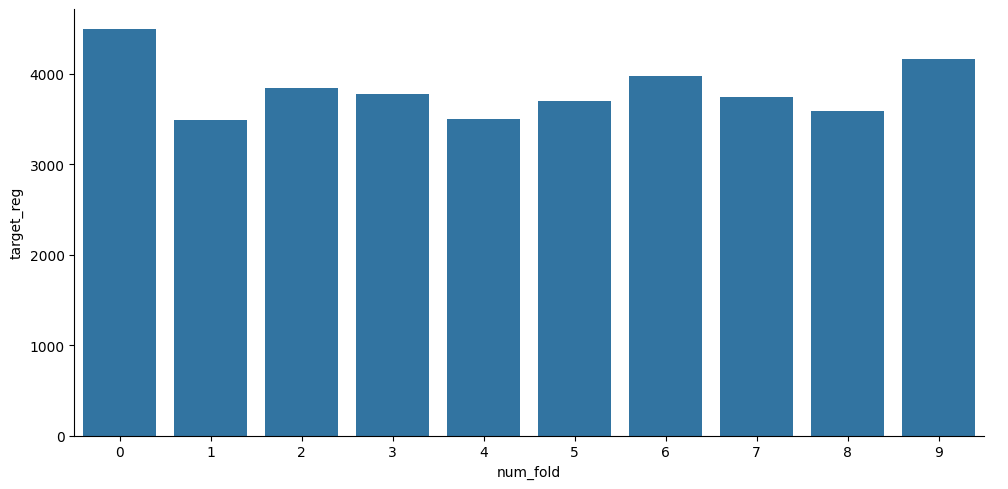

In [107]:
tmp = df.groupby('num_fold', as_index=False)['target_reg'].agg('mean')
sns.catplot(data = tmp, x = 'num_fold', y = 'target_reg', aspect=2, kind="bar");

# Задача на 7-ом шаге урока

In [7]:
# Вспомогательная библиотека для решения
# Документация: https://github.com/trent-b/iterative-stratification

In [8]:
!pip install iterative-stratification -q

In [30]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

In [72]:
path = 'https://stepik.org/media/attachments/lesson/779913/multi_label.csv'
df = pd.read_csv(path)

In [73]:
targets = ['Computer Science', 'Physics', 'Mathematics', 'Statistics',
           'Quantitative Biology', 'Quantitative Finance', 'Chemistry',
           'Astrology', 'Spaceology', 'Life Science', 'Earth Science', 'Data Science']

In [74]:
df

,ID,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance,Chemistry,Astrology,Spaceology,Life Science,Earth Science,Data Science
0,9431,1,0,1,1,0,0,0,0,0,0,0,0
1,7960,1,1,0,1,0,0,0,0,0,0,0,1
2,8578,1,1,0,1,0,0,0,0,0,1,0,0
3,1651,1,0,1,1,0,0,0,0,0,0,0,0
4,4011,1,0,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3819,1,0,0,0,0,0,0,0,0,0,0,0
9996,3817,0,1,0,0,0,0,1,0,0,0,0,1
9997,3816,1,0,0,0,0,0,0,0,0,1,0,0
9998,3814,0,1,0,0,0,0,0,0,0,1,0,1


In [91]:
n_splits = 5

mskf  = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
y = df[targets].values
df['kfold'] = -1

for fold, (train_idx, valid_idx) in enumerate(mskf.split(df, y)):
    df.loc[valid_idx, 'kfold'] = int(fold)

df['kfold'] = df['kfold'].astype(int)
df.to_csv('results/answer_task2.csv', index=False)

In [82]:
tmp = df.groupby(['kfold'], as_index=False).sum()
tmp_melt = tmp.melt(id_vars = 'kfold', value_vars = targets, value_name = 'count', var_name = 'class')
print(tmp_melt.groupby(['class'], as_index=False).std()['count'].mean())

0.34002113116881
